In [117]:
import jax.numpy as jnp
from jax.scipy import linalg
from jax import random
import matplotlib.pyplot as plt

from lqg.tracking import BoundedActor
from lqg import xcorr, LQG, Dynamics, Actor, System

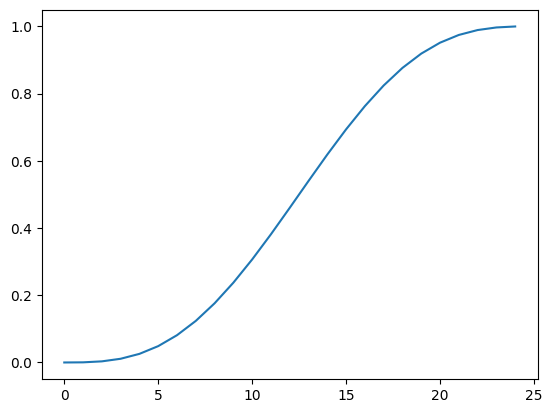

In [118]:
F_rw = 20
F_sim = 500
dt_rw = 1 / F_rw
dt_sim = 1 / F_sim
N = F_sim // F_rw

def g(t, N=50):
    return t / N - jnp.sin(2 * jnp.pi * t / N) / (2 * jnp.pi)


t = jnp.arange(N)
plt.plot(t, g(t, N=N))


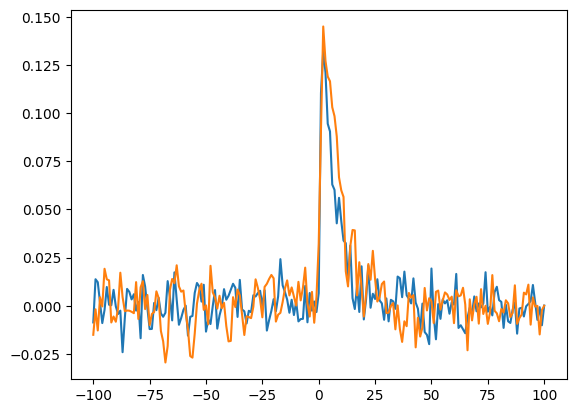

In [133]:
params = {"process_noise": 1.0, "sigma_target": 6.0, "sigma_cursor": 6.0, "action_variability": 0.5, "action_cost": 0.1}


lqg_rw = BoundedActor(dt=dt_rw, T=500, **params)

A = jnp.eye(2)
B = jnp.array([[0], [dt_sim]])
V = jnp.diag(jnp.array([params["process_noise"] / jnp.sqrt(N), params["action_variability"] / jnp.sqrt(N)]))
W = jnp.diag(jnp.array([params["sigma_target"] * jnp.sqrt(N), params["sigma_cursor"] * jnp.sqrt(N)]))
Q = jnp.array([[1.0, -1.0], [-1.0, 1.0]])
R = jnp.eye(1) * params["action_cost"] / N
dynamics_sim = Dynamics(A=A, B=B, V=V, F=jnp.eye(2), W=W, T=N * 500)

A_subj = jnp.array([[1.0, 0., dt_sim], [0.0, 1.0, 0], [0.0, 0.0, 1.0]])
B_subj = jnp.array([[0.0], [dt_sim], [0.]])
V_subj = jnp.diag(jnp.array([params["process_noise"] / jnp.sqrt(N) * 1., params["action_variability"] / jnp.sqrt(N), 0.1]))
Q_subj = linalg.block_diag(Q, jnp.array([[0.]]))

actor_sim = Actor(A=A_subj, B=B_subj, V=V_subj, F=jnp.eye(2, 3), W=W, Q=Q_subj, R=R, T=N * 500)
lqg_sim = System(dynamics=dynamics_sim, actor=actor_sim)

x_rw = lqg_rw.simulate(n=20, rng_key=random.PRNGKey(99999))
x_sim = lqg_sim.simulate(n=20, rng_key=random.PRNGKey(99999))
x_sim = x_sim[:, ::N]

for x in [x_rw, x_sim]:
    vels = jnp.diff(x, axis=-2)

    # plt.plot(x[0, :, 0])  # position
    # plt.plot(x[0, :, 1])  # response
    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=100)

    plt.plot(lags, correls.mean(axis=0))

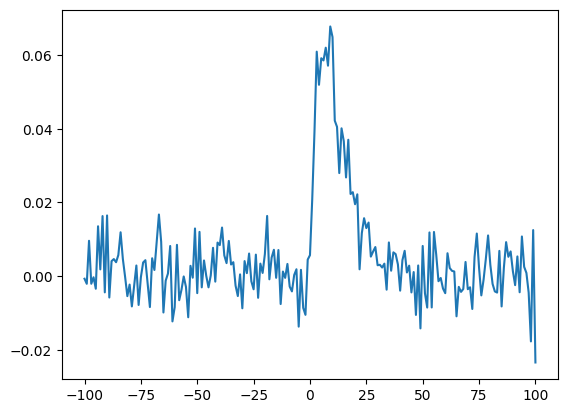

In [ ]:
A = jnp.eye(2)
B = jnp.array([[0.0], [dt_rw]])
V = jnp.diag(jnp.array([1.0, 0.5]))
F = jnp.eye(2)
W = jnp.diag(jnp.array([6.0, 6.0]))

Q = jnp.array([[1., -1.],  [-1.,1.]])
R = jnp.array([[1.]]) * 0.1

In [62]:
model = LQG(A=A, B=B, V=V, F=F, W=W, Q=Q, R=R, T=1_000)
model

In [63]:
x = model.simulate(n=20, rng_key=random.PRNGKey(99999))
# x = x[:, ::N]

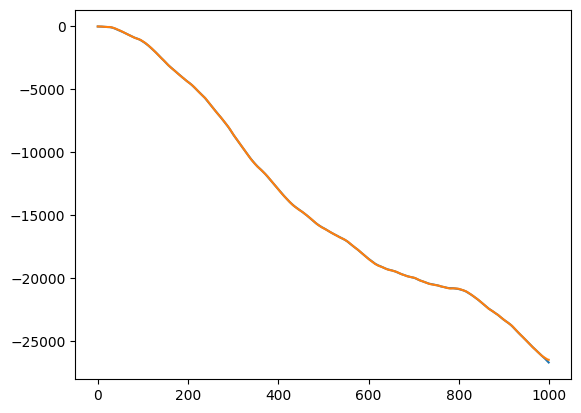

In [64]:
plt.plot(x[0, :, 0])  # position
plt.plot(x[0, :, 2])  # response

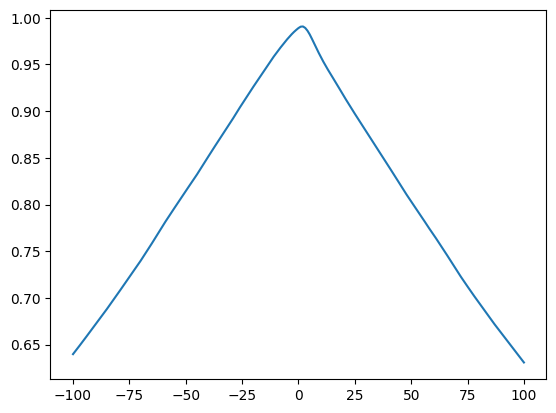

In [65]:
vels = jnp.diff(x, axis=-2)

lags, correls = xcorr(vels[..., 2], vels[..., 0], maxlags=100)

plt.plot(lags, correls.mean(axis=0))
